# Orange County Analysis

In [48]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    policing_summary_table,
    prosecution_rates_by_statute_level,
    add_white_normalized_ratios,
    visualize_policing,
    visualize_prosecution,
    plot_pipeline_disparity_summary
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [30]:
# Load in policing data
policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2023.csv")

<positron-console-cell-30>:2: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [31]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [32]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [43]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_stop"].isin([1, 2])]

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Adds counts, rates, and per-capita rates for stops, searches, and hits
policing_analysis = policing_summary_table(policing, census_coarse)

# Add White-normalized ratios
policing_analysis = add_white_normalized_ratios(
    policing_analysis,
    race_col="Perceived Race",
    metrics=["Stops per 1,000", "Searches per 1,000", "Search Rate", "Hit Rate"]
)

policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000","Stops per 1,000 (White=1)","Searches per 1,000 (White=1)",Search Rate (White=1),Hit Rate (White=1)
0,2019,Asian,3001,111,53,0.036988,0.477477,699124,4.292515,0.158770,0.223299,0.076738,0.343657,1.020814
1,2019,Black/African American,1785,257,102,0.143978,0.396887,49304,36.203959,5.212559,1.883346,2.519379,1.337714,0.848517
2,2019,Hispanic/Latino,14412,2047,806,0.142034,0.393747,1086834,13.260535,1.883452,0.689819,0.910326,1.319660,0.841804
3,2019,Other,3613,116,46,0.032106,0.396552,153072,23.603272,0.757813,1.227853,0.366273,0.298304,0.847800
4,2019,White,23042,2480,1160,0.107630,0.467742,1198655,19.223213,2.068986,1.000000,1.000000,1.000000,1.000000
5,2020,Asian,2356,123,54,0.052207,0.439024,699124,3.369932,0.175934,0.238777,0.107869,0.451759,0.845609
6,2020,Black/African American,1381,217,108,0.157133,0.497696,49304,28.009898,4.401266,1.984643,2.698516,1.359699,0.958616
7,2020,Hispanic/Latino,11782,2023,885,0.171703,0.437469,1086834,10.840662,1.861370,0.768116,1.141248,1.485776,0.842613
8,2020,Other,2632,135,56,0.051292,0.414815,153072,17.194523,0.881938,1.218319,0.540736,0.443838,0.798978
9,2020,White,16917,1955,1015,0.115564,0.519182,1198655,14.113319,1.630995,1.000000,1.000000,1.000000,1.000000


## Prosecution Rates

In [39]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

# Add White-normalized rates
prosecution_analysis = add_white_normalized_ratios(
    prosecution_analysis,
    race_col="Canonical Race",
    strata_cols=["statute_level"],
    metrics=["Charge Rate", "Enhancement Rate"]
)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Charge Rate,Enhancement Rate,Charge Rate (White=1),Enhancement Rate (White=1)
0,Asian,2021,Felony,1251,1.0,0.000799,1.0,0.141373
1,Asian,2021,Infraction,2,1.0,0.000000,1.0,NaN
2,Asian,2021,Misdemeanor,2768,1.0,0.142702,1.0,1.560807
3,Asian,2022,Felony,1090,1.0,0.003670,1.0,0.670183
4,Asian,2022,Infraction,4,1.0,0.000000,1.0,NaN
5,Asian,2022,Misdemeanor,2289,1.0,0.174749,1.000049,1.520787
6,Asian,2023,Felony,876,1.0,0.001142,1.0,0.278824
7,Asian,2023,Infraction,3,1.0,0.000000,1.0,NaN
8,Asian,2023,Misdemeanor,1325,1.0,0.163774,1.0,1.623948
9,Black/African American,2021,Felony,1689,1.0,0.008289,1.0,1.465956


# Visualizations

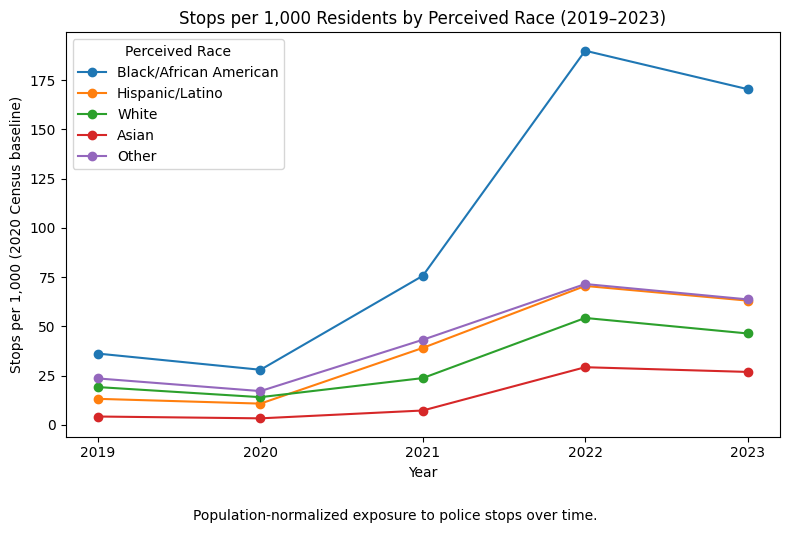

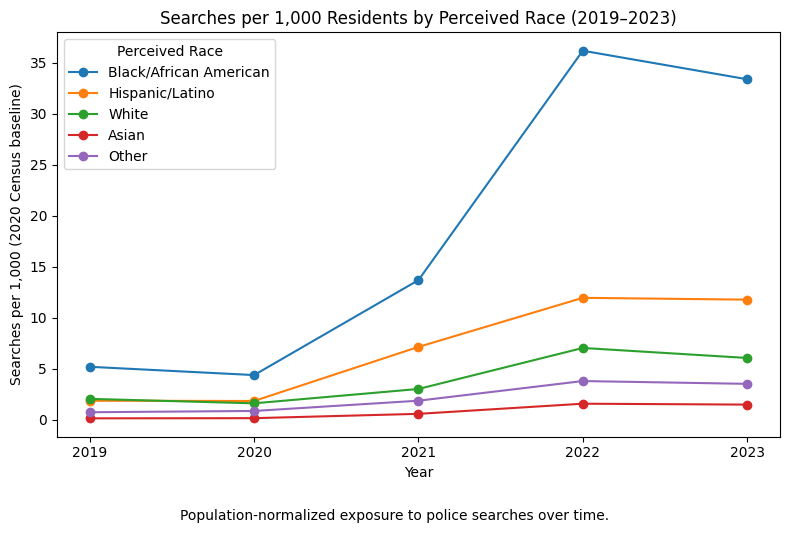

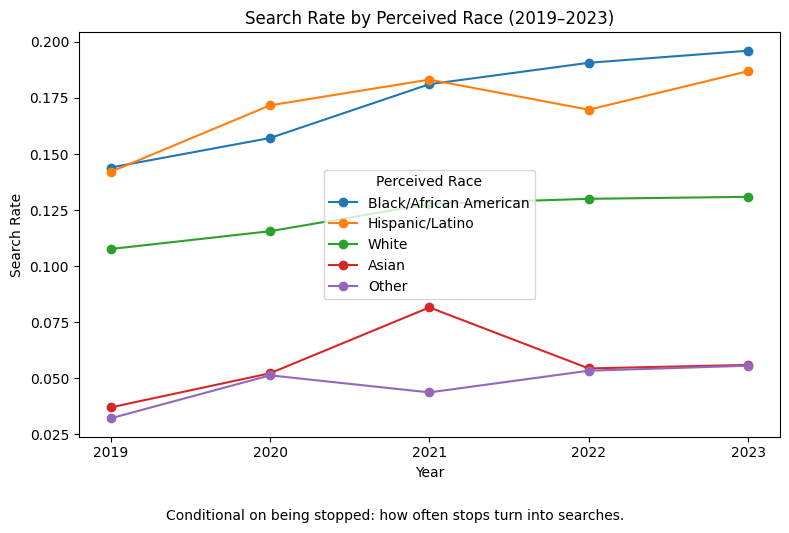

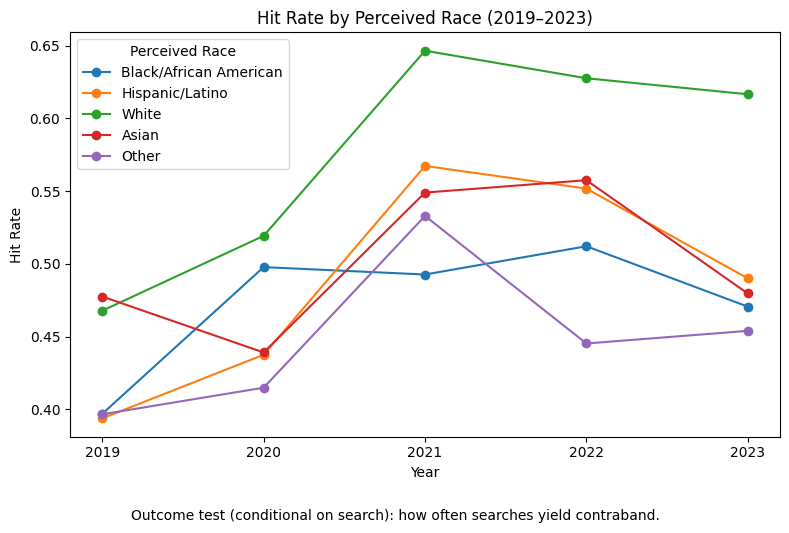

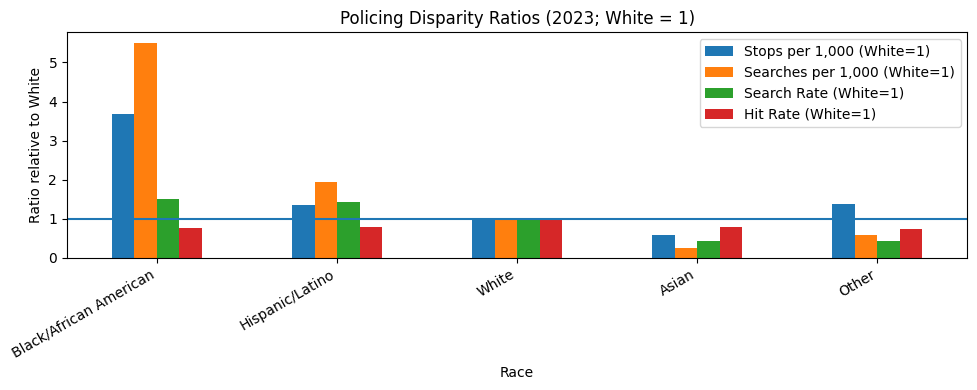

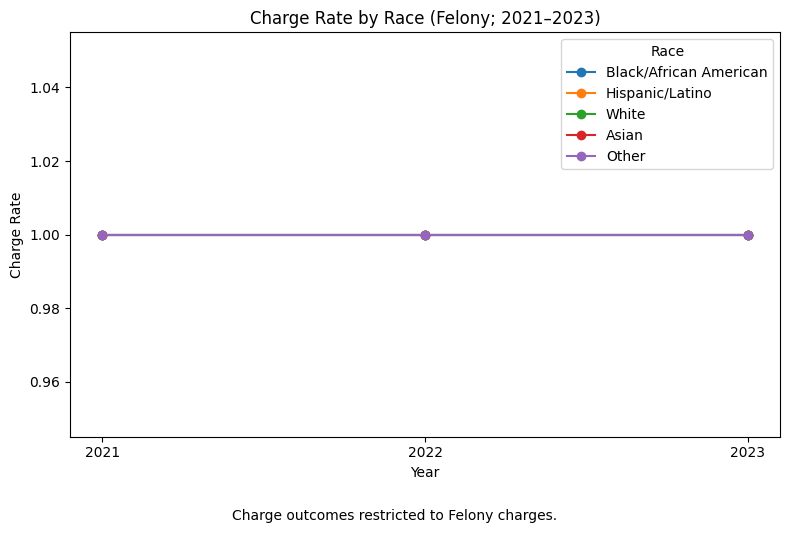

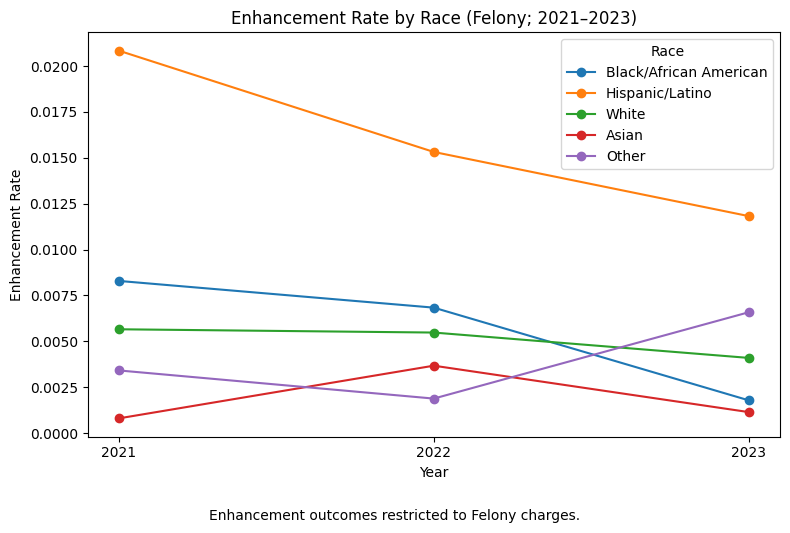

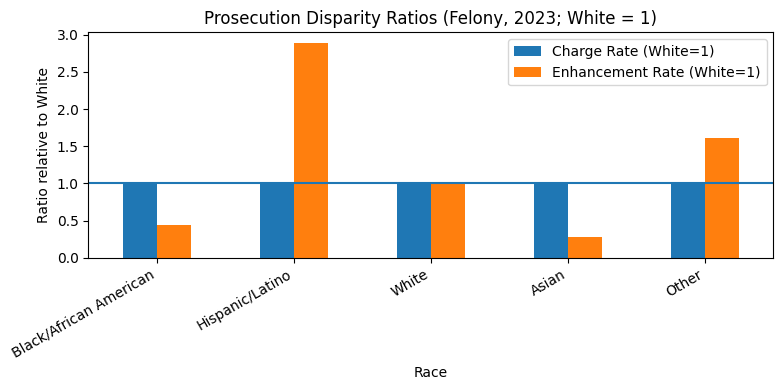

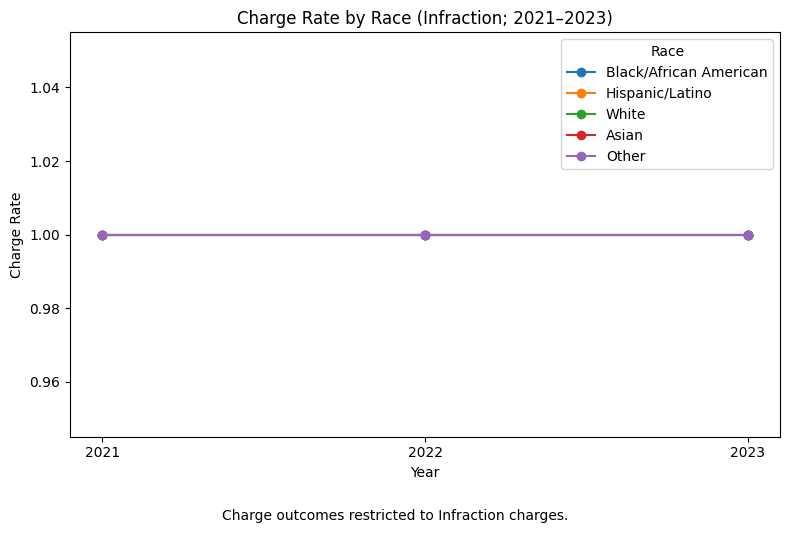

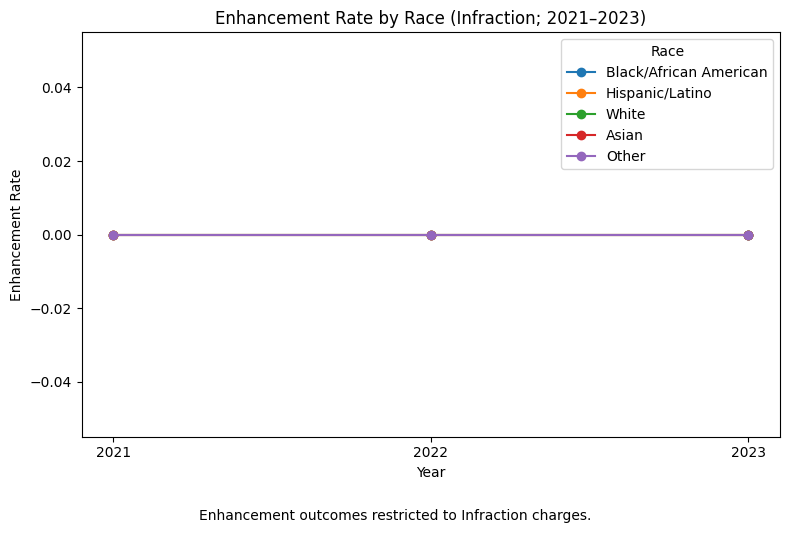

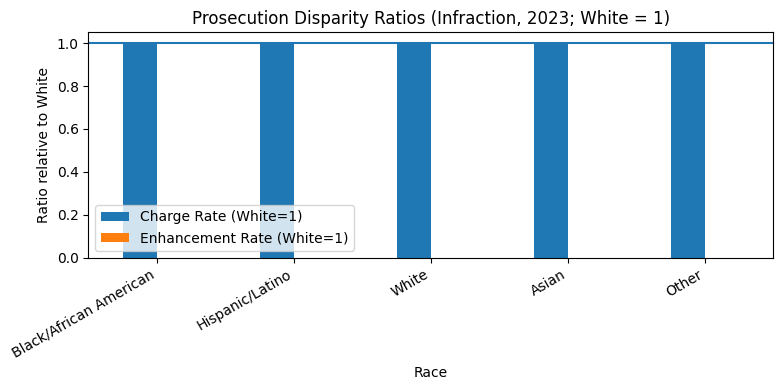

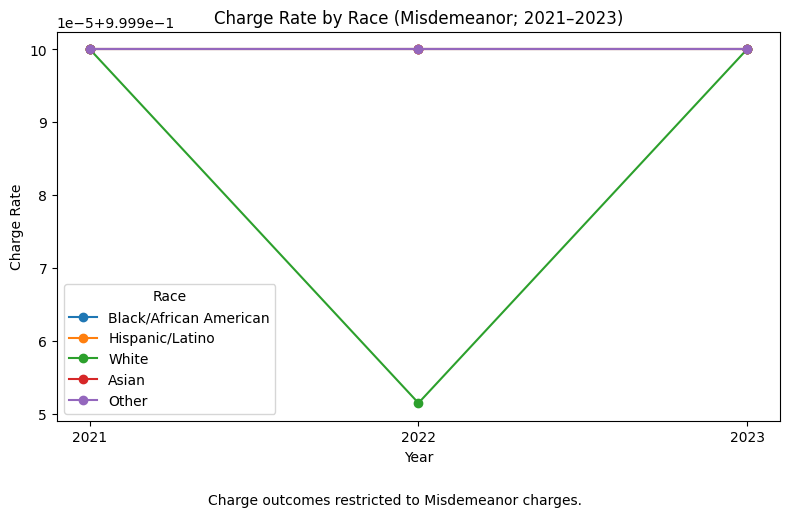

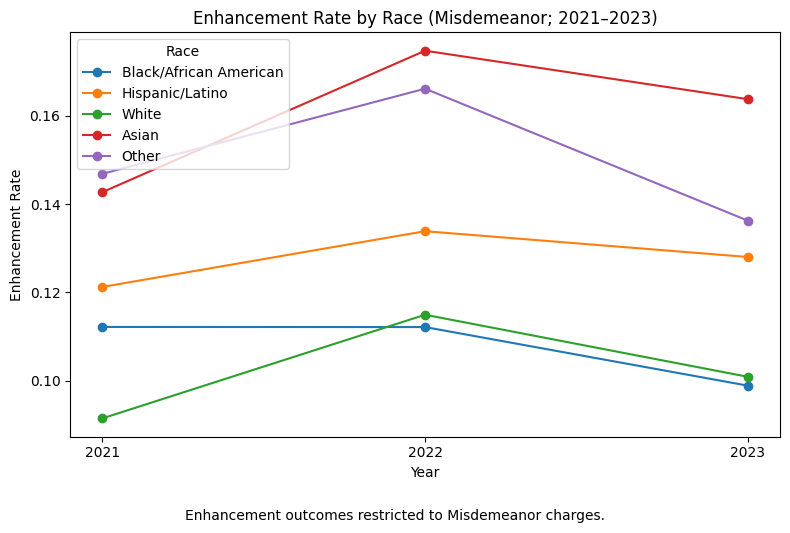

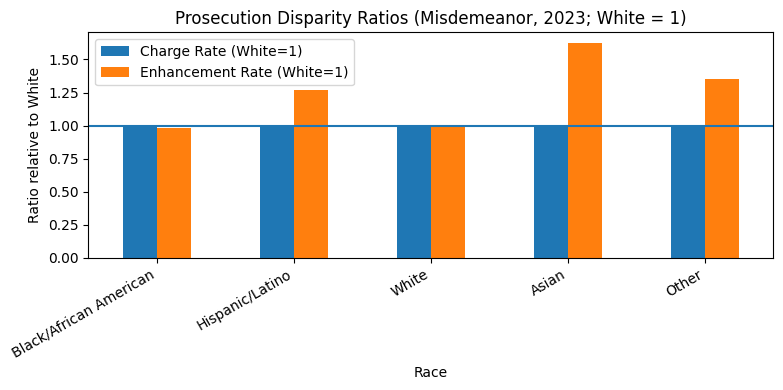

In [45]:
visualize_policing(policing_analysis)
visualize_prosecution(prosecution_analysis)

In [ ]:
prosecution["was_filed_by_da"].value_counts(normalize=True)

was_filed_by_da
True     0.999838
False    0.000162
Name: proportion, dtype: float64

# Discussion

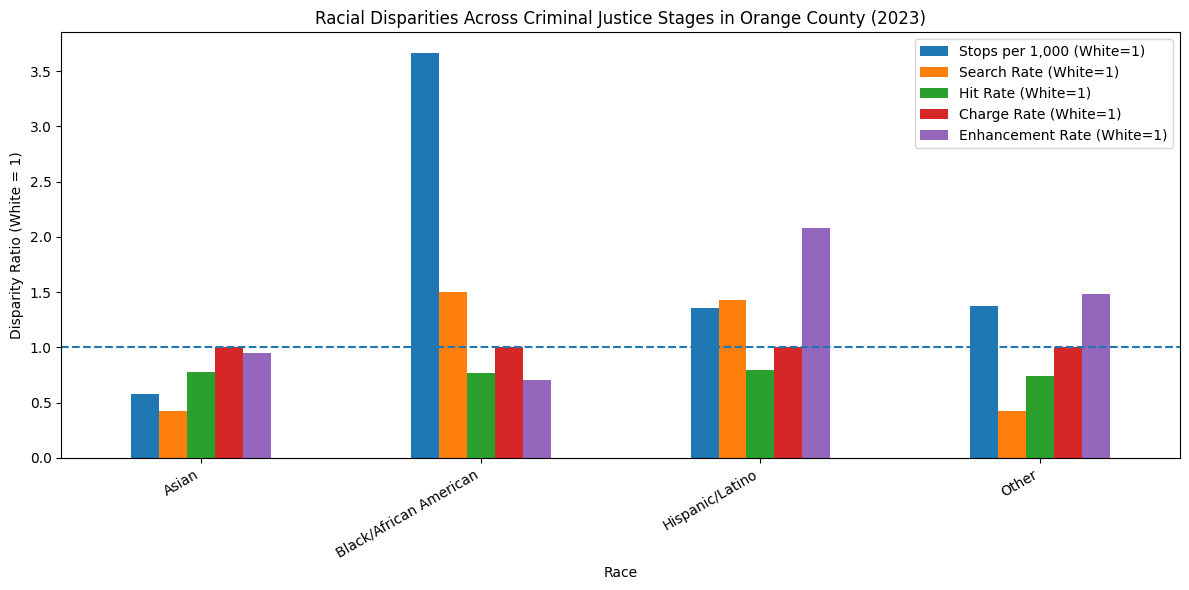

In [50]:
plot_pipeline_disparity_summary(policing_analysis, prosecution_analysis)

This figure presents White-normalized disparity ratios across key stages of the criminal justice process. Each bar shows how a racial group’s rate compares to White individuals in 2023 (White = 1, indicated by the dashed reference line). Values greater than 1 represent higher rates relative to White individuals, while values below 1 represent lower rates.

Black/African American individuals experience substantially higher stop rates (approximately 3.7 times that of White individuals) and elevated search rates, indicating disproportionate exposure at the policing stage. However, hit rates are lower relative to White individuals, suggesting searches are less likely to yield contraband. At the prosecution stage, charge rates are roughly similar across groups, while enhancement rates vary — particularly elevated for Hispanic/Latino and “Other” individuals.

Overall, disparities appear largest at the initial policing stage and evolve differently as cases progress through the justice system.